# Welcome to Colab!

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2956 entries, 0 to 2955
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2956 non-null   object 
 1   Open       2956 non-null   float64
 2   High       2956 non-null   float64
 3   Low        2956 non-null   float64
 4   Close      2956 non-null   float64
 5   Adj Close  2956 non-null   float64
 6   Volume     2956 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 161.8+ KB


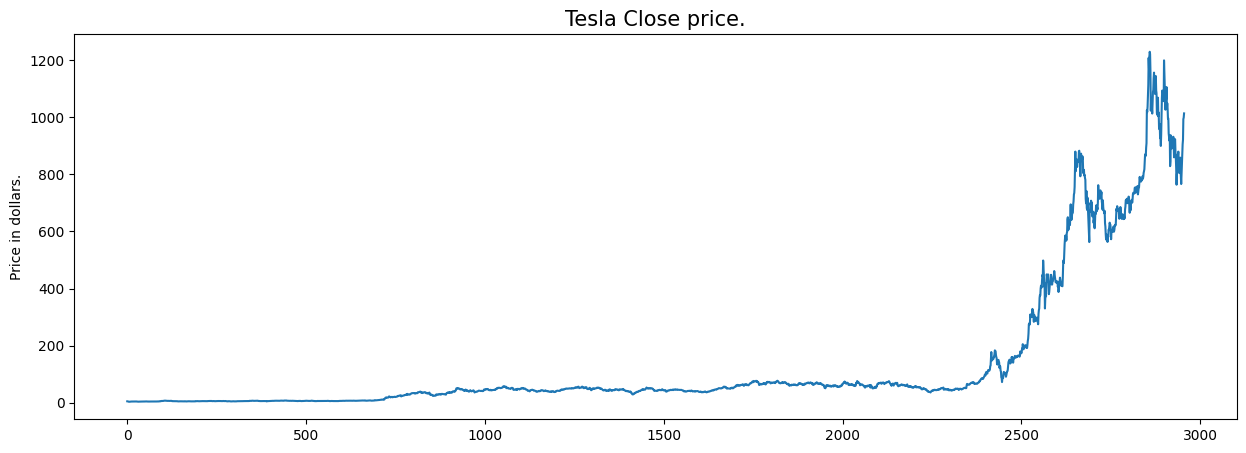

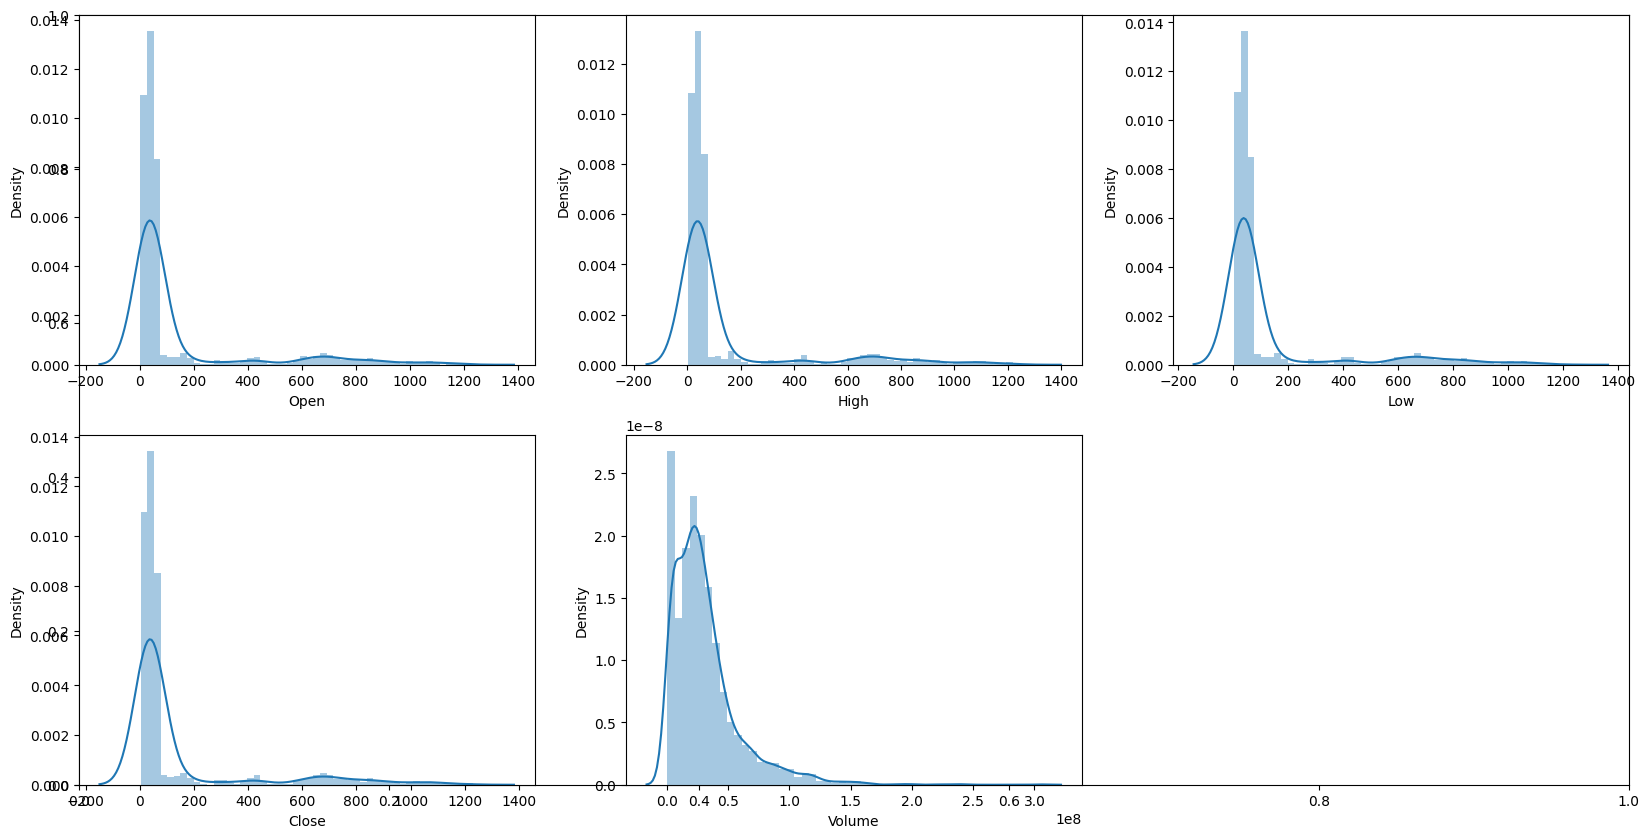

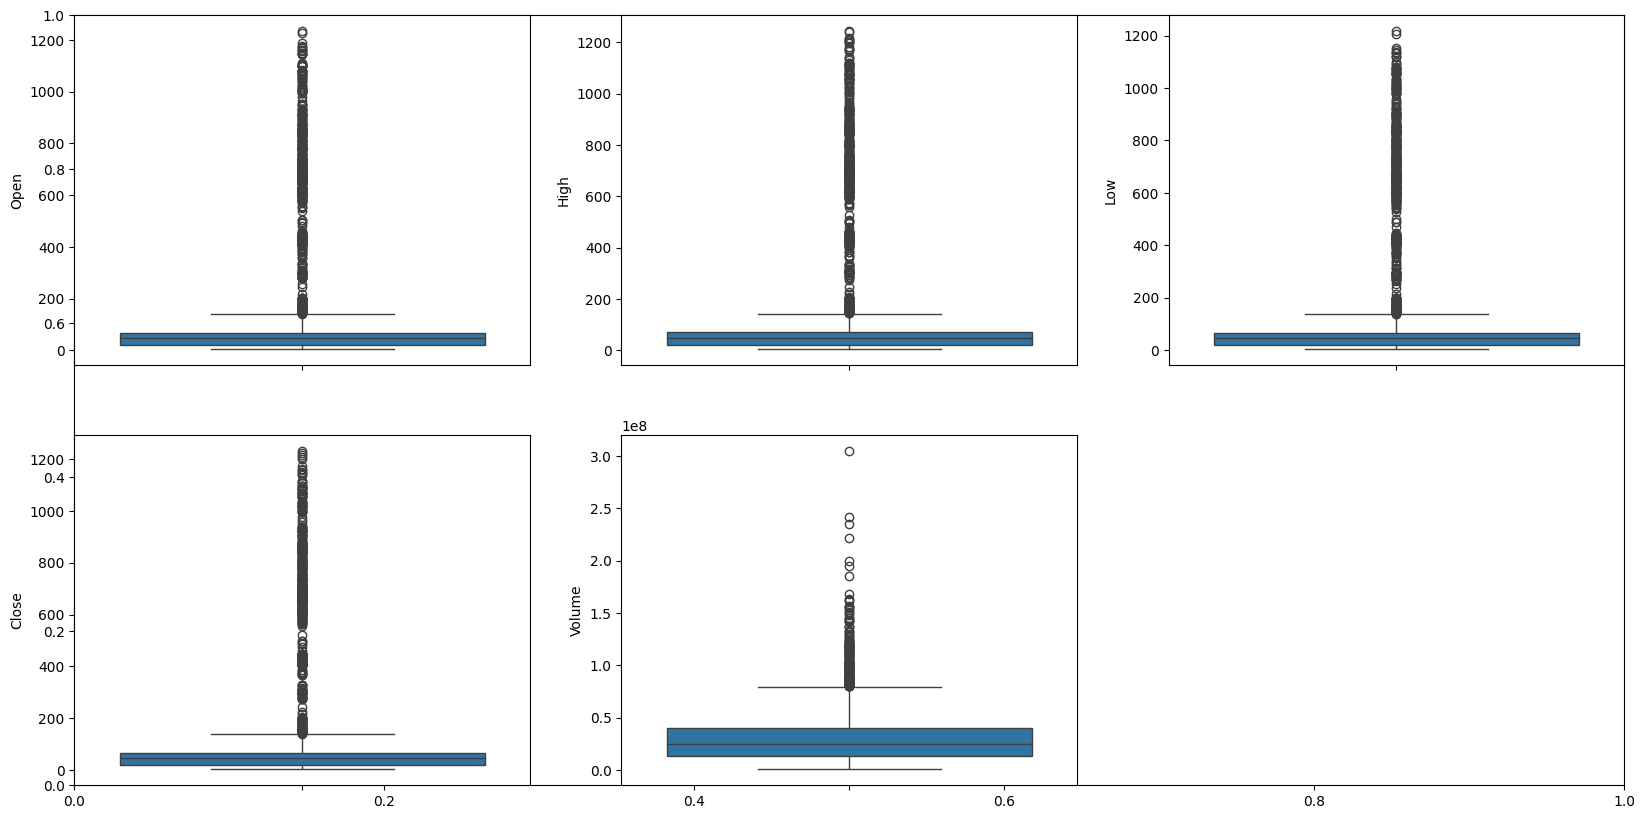

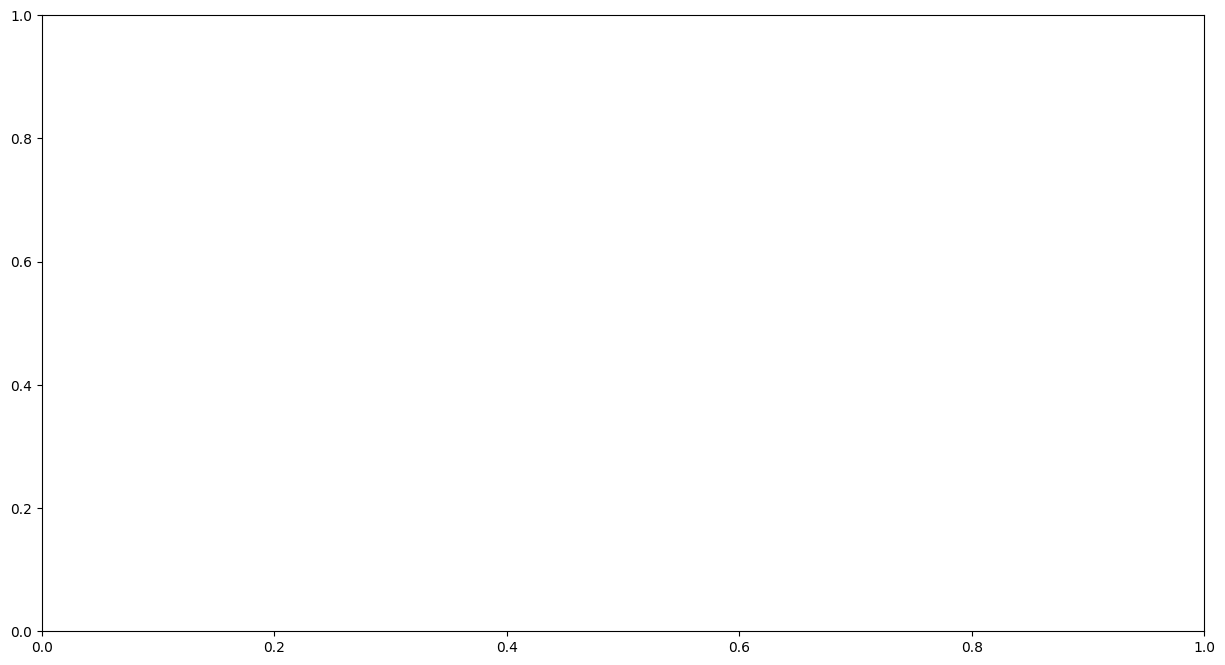

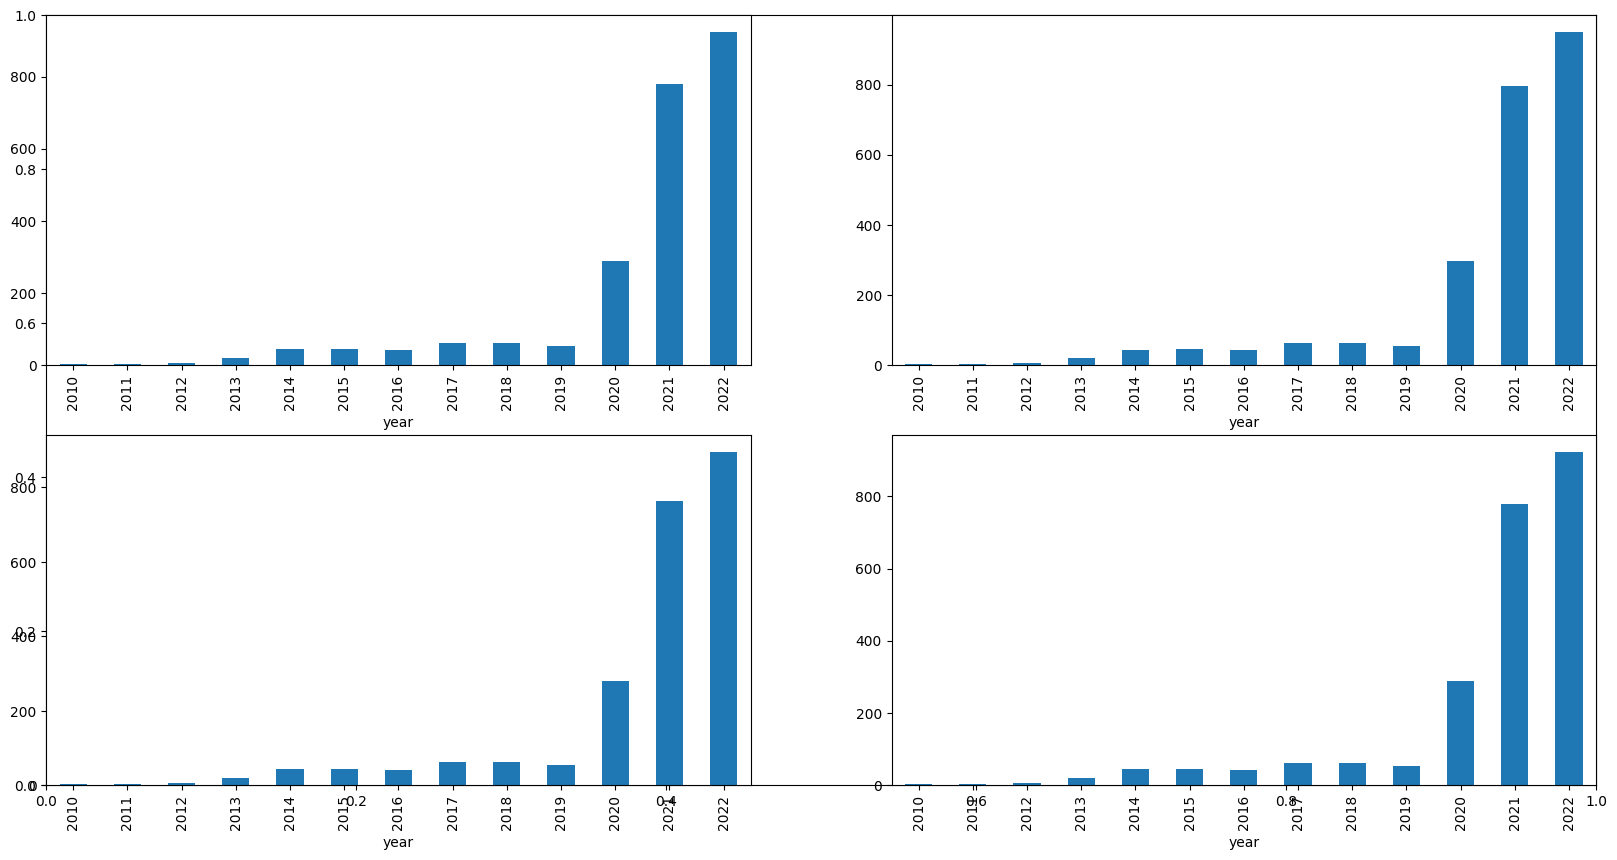

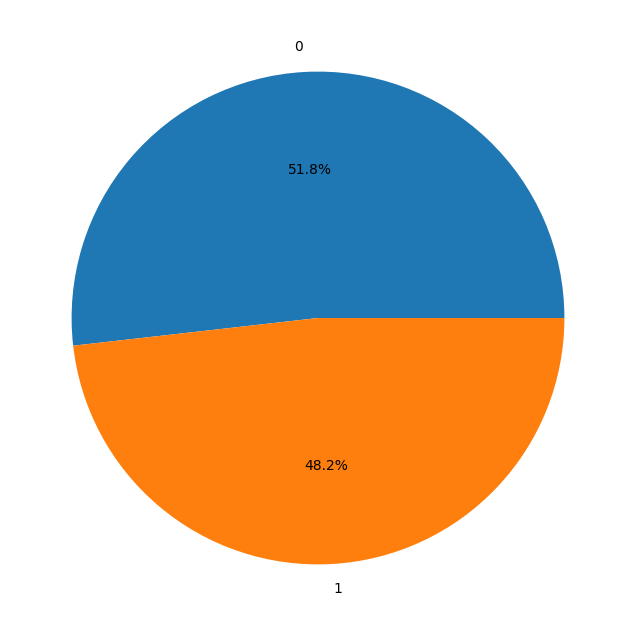

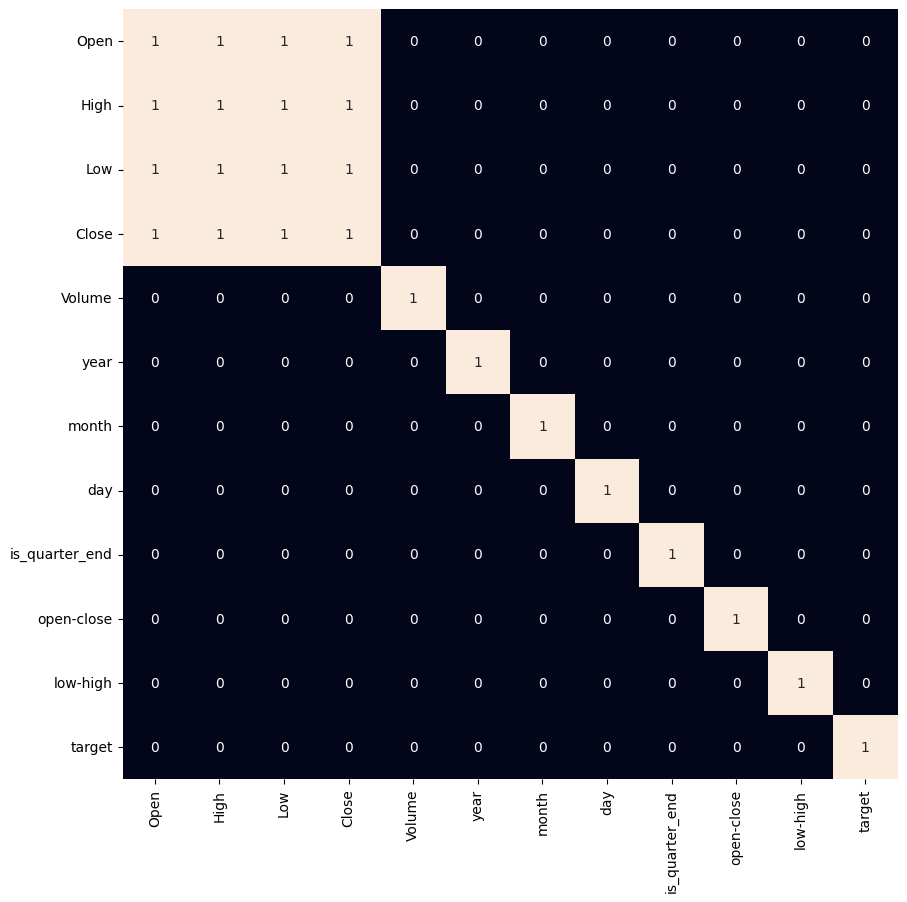

LogisticRegression() : 
Training Accuracy :  0.5118351336744182
Validation Accuracy :  0.5079337899543379

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) : 
Training Accuracy :  0.9997162392327638
Validation Accuracy :  0.46059931506849316

SVC(probability=True) : 
Training Accuracy : 

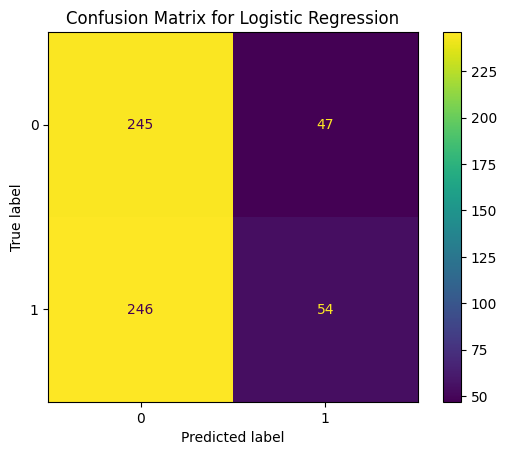

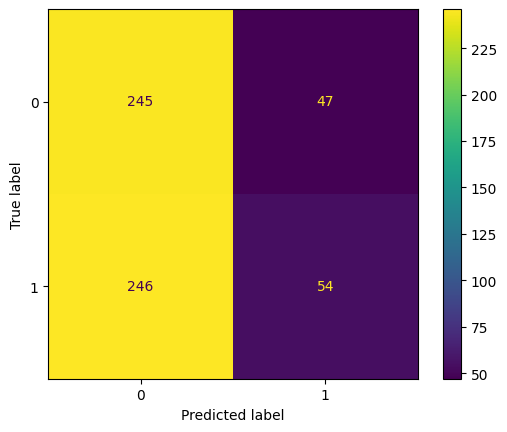

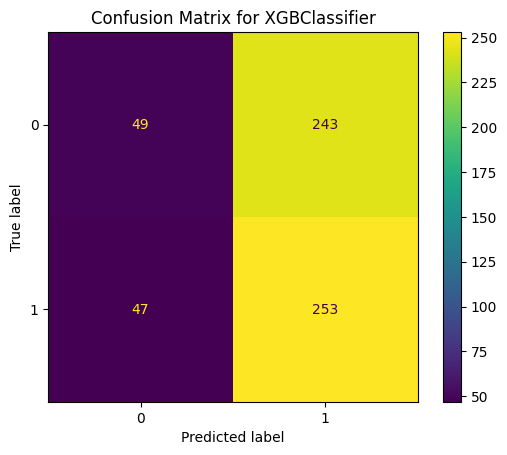

Classification Report for XGBClassifier:
              precision    recall  f1-score   support

           0       0.51      0.17      0.25       292
           1       0.51      0.84      0.64       300

    accuracy                           0.51       592
   macro avg       0.51      0.51      0.44       592
weighted avg       0.51      0.51      0.45       592

Epoch 1/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.3250 - mean_absolute_error: 0.3336
Epoch 2/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0136 - mean_absolute_error: 0.0565
Epoch 3/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0090 - mean_absolute_error: 0.0466
Epoch 4/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0127 - mean_absolute_error: 0.0622
Epoch 5/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0084 - mean_absolute_error: 0.0491
Epoch 6/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0085 - mean_absolute_error: 0.0550
Epoch 7/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/ste

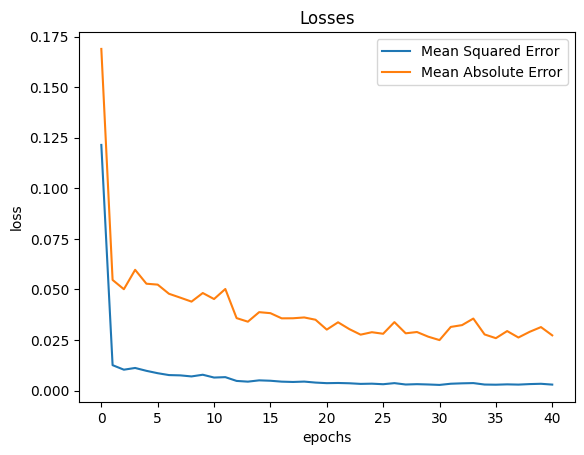

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
RMSE: 2.58


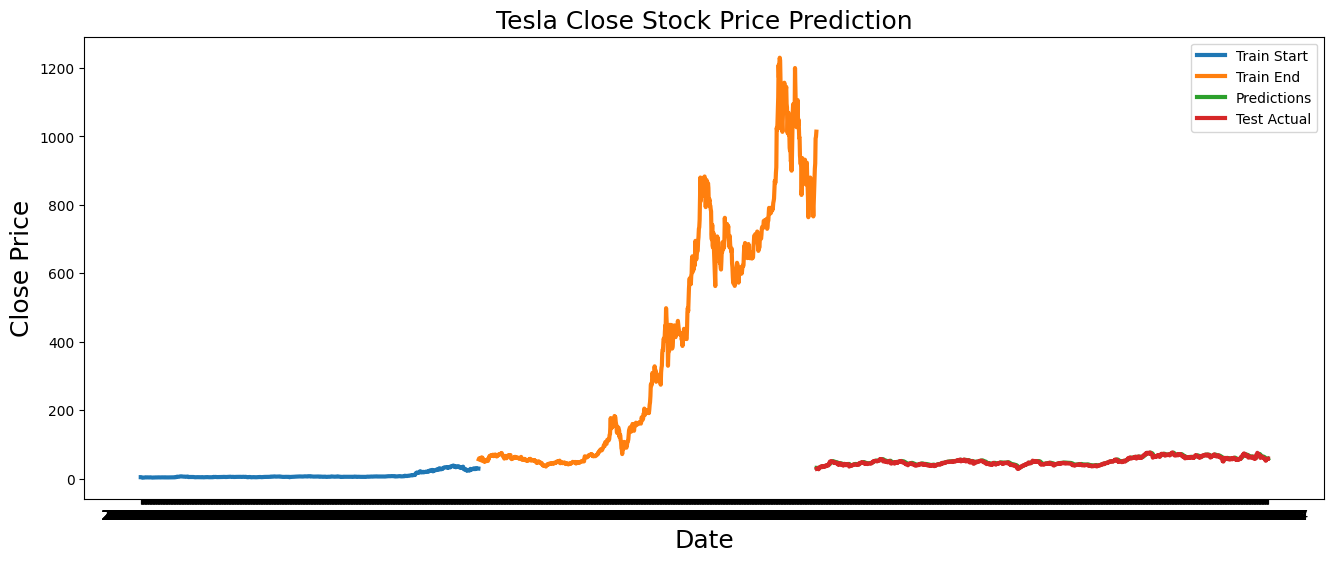

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
!pip install xgboost
!pip install imblearn
!pip install tensorflow
import keras
from xgboost import XGBClassifier
from sklearn import metrics
from imblearn.over_sampling import RandomOverSampler
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from keras.layers import Dense, LSTM, Dropout
from sklearn.metrics import mean_squared_error, mean_absolute_error


import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv('/content/TSLA.csv')
df.head()

df.shape

df.info()

df.describe()

plt.figure(figsize=(15,5))
plt.plot(df['Close'])
plt.title('Tesla Close price.', fontsize=15)
plt.ylabel('Price in dollars.')
plt.show()

df.head()


df[df['Close'] == df['Adj Close']].shape

df = df.drop(['Adj Close'], axis=1)

df.isnull().sum()



features = ['Open', 'High', 'Low', 'Close', 'Volume']

plt.subplots(figsize=(20,10))

for i, col in enumerate(features):
  plt.subplot(2,3,i+1)
  sb.distplot(df[col])
plt.show()


plt.subplots(figsize=(20,10))
for i, col in enumerate(features):
  plt.subplot(2,3,i+1)
  sb.boxplot(df[col])
plt.show()

splitted = df['Date'].str.split('-', expand=True)

df['year'] = splitted[0].astype('int')
df['month'] = splitted[1].astype('int')
df['day'] = splitted[2].astype('int')

df.head()

df['is_quarter_end'] = np.where(df['month']%3==0,1,0)
df.head()

plt.subplots(figsize=(15,8))

data_grouped = df.drop('Date', axis=1).groupby('year').mean()
plt.subplots(figsize=(20,10))

for i, col in enumerate(['Open', 'High', 'Low', 'Close']):
  plt.subplot(2,2,i+1)
  data_grouped[col].plot.bar()
plt.show()

plt.subplots(figsize=(15,8))

df.drop('Date', axis=1).groupby('is_quarter_end').mean()
df['open-close']  = df['Open'] - df['Close']
df['low-high']  = df['Low'] - df['High']
df['target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)

plt.pie(df['target'].value_counts().values,
        labels=[0, 1], autopct='%1.1f%%')
plt.show()

plt.figure(figsize=(10, 10))

sb.heatmap(df.drop('Date', axis=1).corr() > 0.9, annot=True, cbar=False)
plt.show()


X = df[['open-close', 'low-high', 'year', 'month', 'day', 'is_quarter_end', 'Volume', 'Open', 'High', 'Low', 'Close']]
Y = df['target']

X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

ros = RandomOverSampler(random_state=42)
X, Y = ros.fit_resample(X_train, Y_train)

scaler = StandardScaler()
scaler.fit(X)
X_val = scaler.transform(X_val)

from sklearn.neighbors import KNeighborsClassifier

models = [LogisticRegression(), XGBClassifier(), SVC(kernel='rbf', probability=True), KNeighborsClassifier()]

for i in range(4):
  models[i].fit(X, Y)

  print(f'{models[i]} : ')

  train_preds = models[i].predict_proba(X)
  print('Training Accuracy : ', metrics.roc_auc_score(Y, train_preds[:,1]))

  val_preds = models[i].predict_proba(X_val)
  print('Validation Accuracy : ', metrics.roc_auc_score(Y_val, val_preds[:,1]))
  print()

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn import metrics


ConfusionMatrixDisplay.from_estimator(models[0], X_val, Y_val)
plt.title('Confusion Matrix for Logistic Regression')

ConfusionMatrixDisplay.from_estimator(models[0], X_val, Y_val)
plt.show()




import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn import metrics


ConfusionMatrixDisplay.from_estimator(models[1], X_val, Y_val)
plt.title('Confusion Matrix for XGBClassifier')
plt.show()

print("Classification Report for XGBClassifier:")
print(metrics.classification_report(Y_val, models[1].predict(X_val)))

data = df.filter(['Close'])
dataset = data.values

total_len = len(dataset)
lookback_window = 60

first_train_len = int(total_len * 0.3)
last_train_len = int(total_len * 0.3)

if first_train_len < lookback_window:
    print(f"Warning: First training segment length ({first_train_len}) is less than lookback_window ({lookback_window}). Adjusting to {lookback_window}.")
    first_train_len = lookback_window

if last_train_len < lookback_window:
    print(f"Warning: Last training segment length ({last_train_len}) is less than lookback_window ({lookback_window}). Adjusting to {lookback_window}.")
    last_train_len = lookback_window

train_data_segment1_unscaled = dataset[0 : first_train_len, :]
train_data_segment2_unscaled = dataset[total_len - last_train_len : total_len, :]
test_data_middle_unscaled = dataset[first_train_len : total_len - last_train_len, :]

combined_train_unscaled = np.concatenate((train_data_segment1_unscaled, train_data_segment2_unscaled), axis=0)

scaler = StandardScaler()
scaler.fit(combined_train_unscaled)

train_data_segment1_scaled = scaler.transform(train_data_segment1_unscaled)
train_data_segment2_scaled = scaler.transform(train_data_segment2_unscaled)
test_data_middle_scaled = scaler.transform(test_data_middle_unscaled)

x_train_sequences = []
y_train_sequences = []

if len(train_data_segment1_scaled) >= lookback_window:
    for i in range(lookback_window, len(train_data_segment1_scaled)):
        x_train_sequences.append(train_data_segment1_scaled[i-lookback_window:i, 0])
        y_train_sequences.append(train_data_segment1_scaled[i, 0])

if len(train_data_segment2_scaled) >= lookback_window:
    for i in range(lookback_window, len(train_data_segment2_scaled)):
        x_train_sequences.append(train_data_segment2_scaled[i-lookback_window:i, 0])
        y_train_sequences.append(train_data_segment2_scaled[i, 0])

x_train = np.array(x_train_sequences)
y_train = np.array(y_train_sequences)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))


if first_train_len < lookback_window:
    print("Error: First training segment is too short to provide lookback for the test set. Cannot create x_test.")
    x_test = np.array([])
    y_test_for_rmse = np.array([])
elif len(test_data_middle_unscaled) == 0:
    print("Warning: The middle test segment is empty. No test data to predict.")
    x_test = np.array([])
    y_test_for_rmse = np.array([])
else:
    data_for_test_x_unscaled = dataset[first_train_len - lookback_window : total_len - last_train_len, :]
    data_for_test_x_scaled = scaler.transform(data_for_test_x_unscaled)

    x_test_sequences = []
    for i in range(lookback_window, len(data_for_test_x_scaled)):
        x_test_sequences.append(data_for_test_x_scaled[i-lookback_window:i, 0])

    x_test = np.array(x_test_sequences)
    x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

    y_test_for_rmse = test_data_middle_scaled[0:len(x_test), 0]


model = Sequential([
    LSTM(50, return_sequences= True, input_shape= (x_train.shape[1], 1)),
    LSTM(64, return_sequences= False),
    Dense(32),
    Dense(16),
    Dense(1)
])

model.compile(optimizer= 'adam', loss= 'mse' , metrics= ["mean_absolute_error"])
callbacks = [EarlyStopping(monitor= 'loss', patience= 10 , restore_best_weights= True)]
history = model.fit(x_train, y_train, epochs= 100, batch_size= 32 , callbacks= callbacks )
plt.plot(history.history["loss"])
plt.plot(history.history["mean_absolute_error"])
plt.legend(['Mean Squared Error','Mean Absolute Error'])
plt.title("Losses")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

if x_test.size > 0:
    predictions = model.predict(x_test)
    predictions = scaler.inverse_transform(predictions)
    y_test_inverse = scaler.inverse_transform(y_test_for_rmse.reshape(-1, 1))

    RMSE = np.sqrt(mean_squared_error(y_test_inverse, predictions)).round(2)
    print(f'RMSE: {RMSE}')
else:
    print("Not enough test data to make predictions or calculate RMSE.")
    predictions = np.array([])
    y_test_inverse = np.array([])


plt.figure(figsize= (16, 6))
plt.title('Tesla Close Stock Price Prediction', fontsize= 18)
plt.xlabel('Date', fontsize= 18)
plt.ylabel('Close Price', fontsize= 18)

dates = df['Date']

plt.plot(dates.iloc[0:first_train_len], train_data_segment1_unscaled, linewidth=3, label='Train Start')
plt.plot(dates.iloc[total_len - last_train_len:total_len], train_data_segment2_unscaled, linewidth=3, label='Train End')

if predictions.size > 0:
    predicted_dates_for_plot = dates.iloc[first_train_len : first_train_len + predictions.shape[0]]
    plt.plot(predicted_dates_for_plot, predictions, linewidth=3, label='Predictions')

if len(test_data_middle_unscaled) > 0:
    plt.plot(dates.iloc[first_train_len : total_len - last_train_len], test_data_middle_unscaled, linewidth=3, label='Test Actual')



plt.legend()
plt.show()